# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [4]:
# untuk plot Q-Q
import scipy.stats as stats

In [5]:
df_california = pd.read_csv('california_dataset.csv')

In [6]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

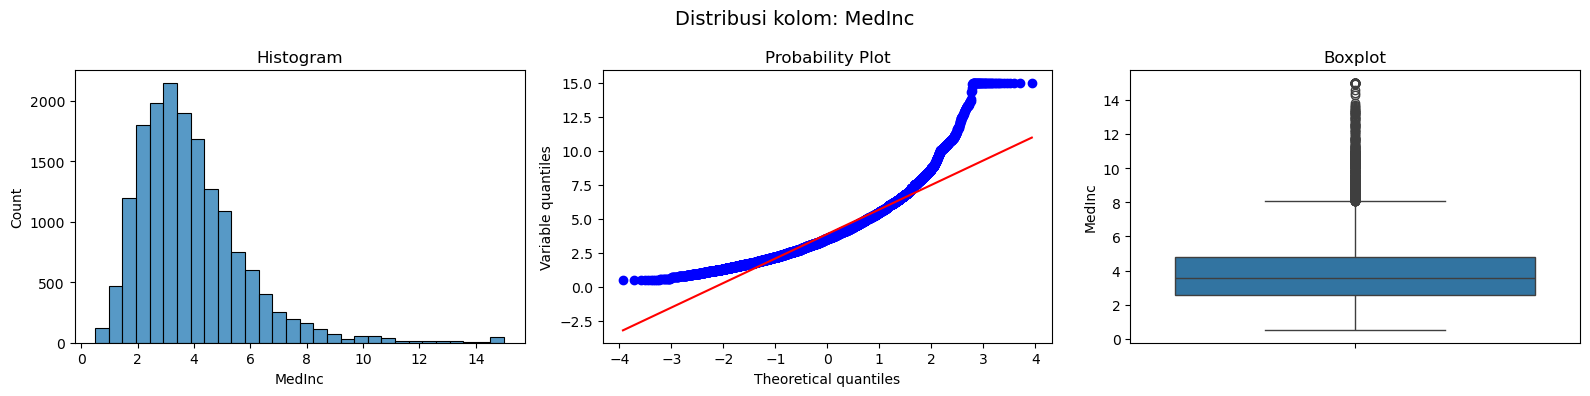

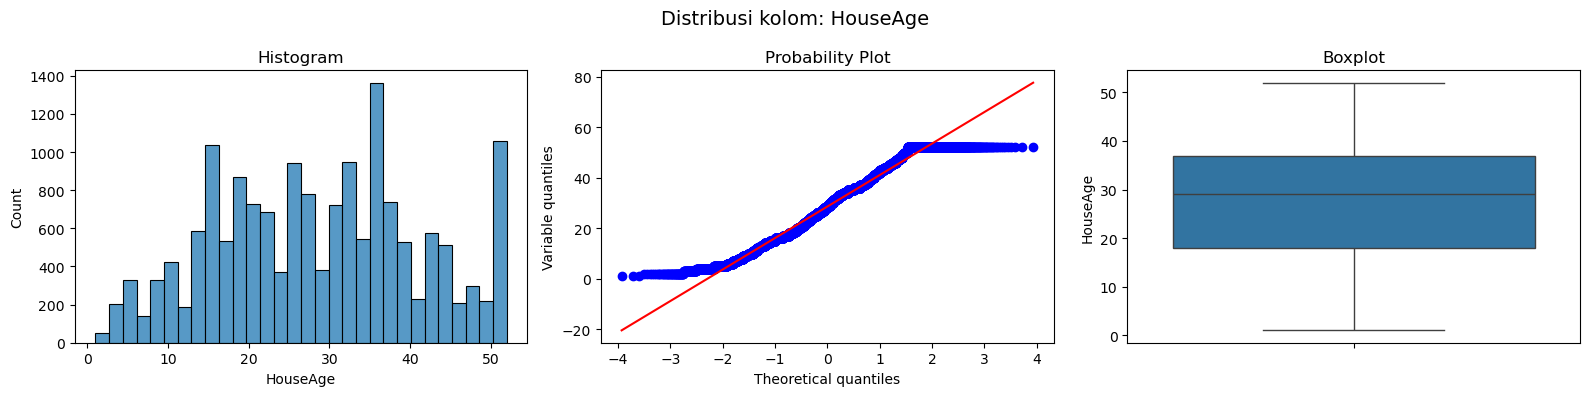

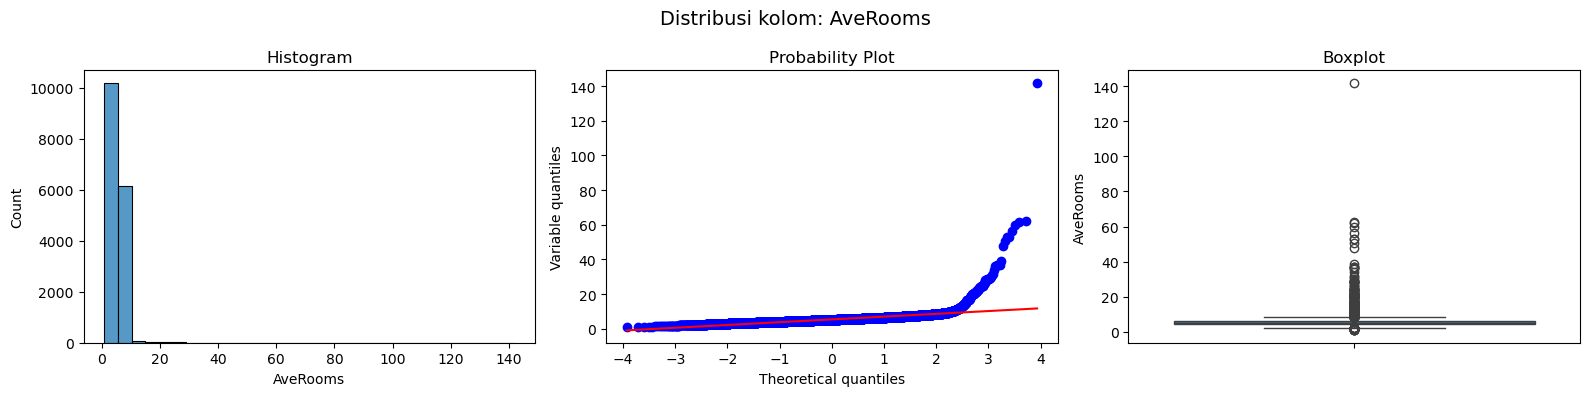

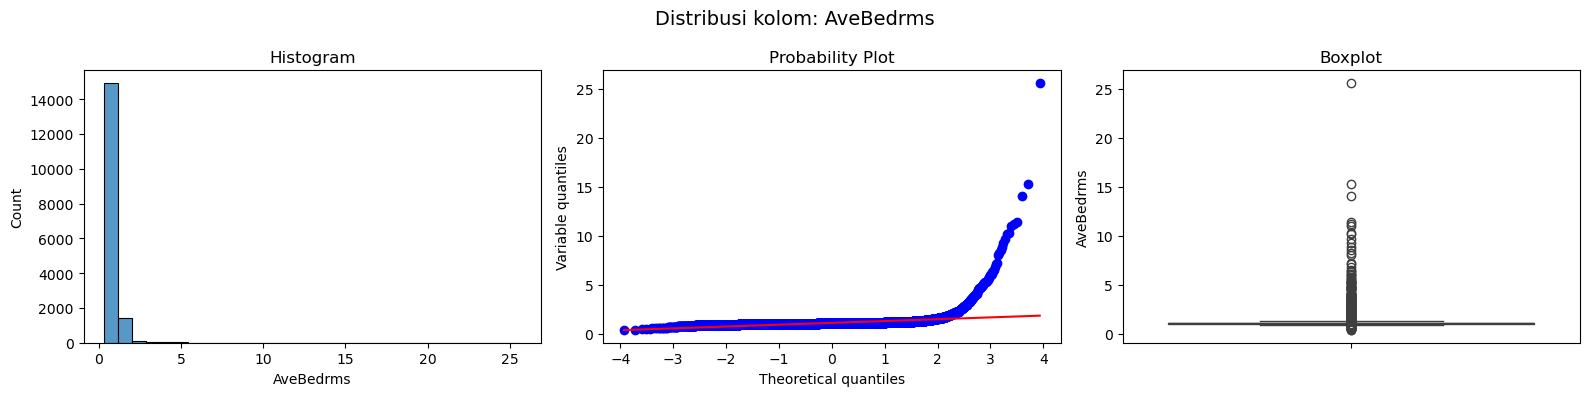

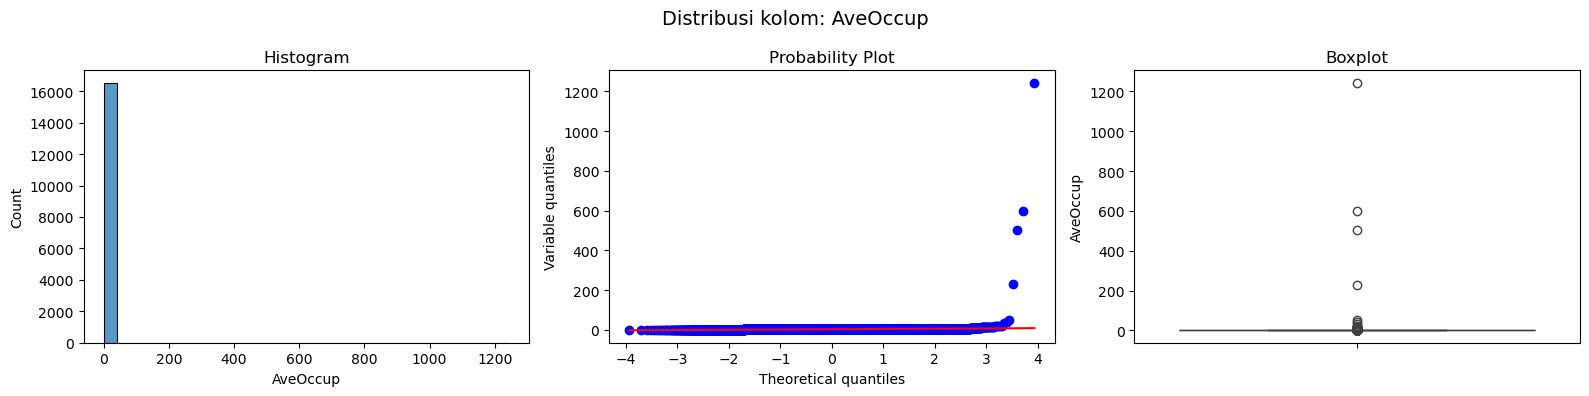

In [9]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

def check_plot(df, variable):
    
    plt.figure(figsize=(16, 4))

    # box dan histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')
    plt.suptitle(f'Distribusi kolom: {variable}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Looping plot 
for kolom in kolom_kolom:
    check_plot(train_clfr, kolom)



### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

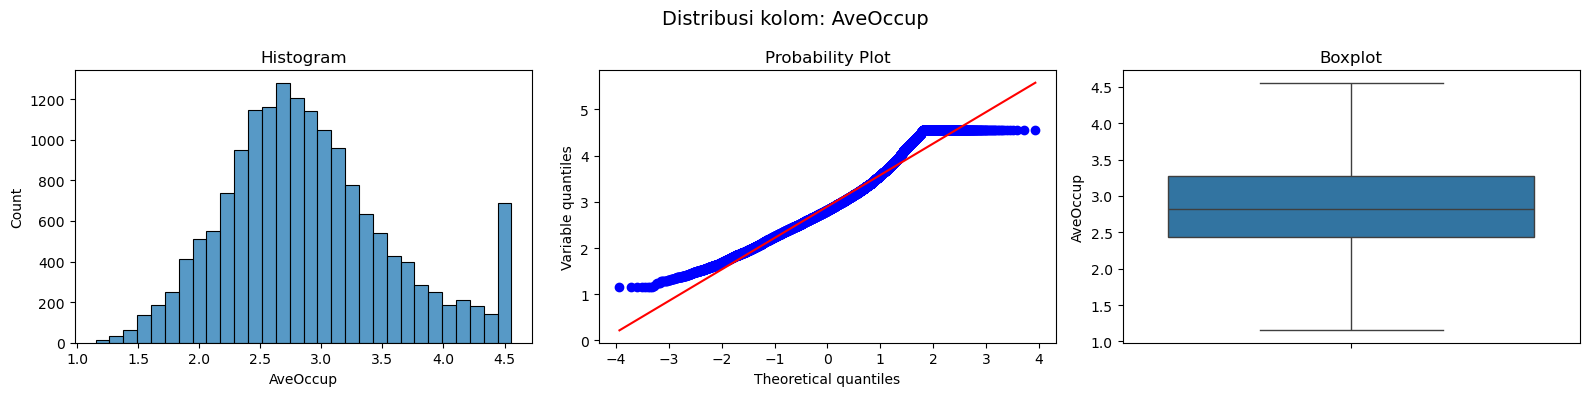

In [22]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali

def find_outlier_boundary(df, variable):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)
    return upper_boundary, lower_boundary

#panggil ualng cek dsitribusi
check_plot(train_clfr, 'AveOccup')
AveOccup_upper_limit, AveOccup_lower_limit = find_outlier_boundary(train_clfr, 'AveOccup')
train_clfr['AveOccup'] = np.where(
    train_clfr['AveOccup'] > AveOccup_upper_limit, AveOccup_upper_limit,
    np.where(
        train_clfr['AveOccup'] < AveOccup_lower_limit, AveOccup_lower_limit,
        train_clfr['AveOccup']
        )
    )

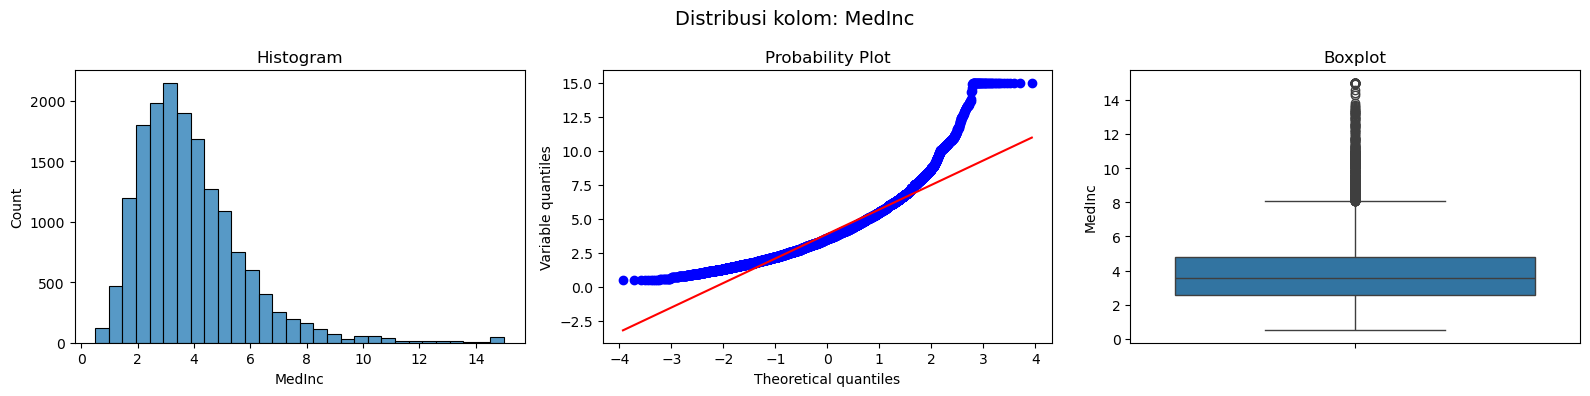

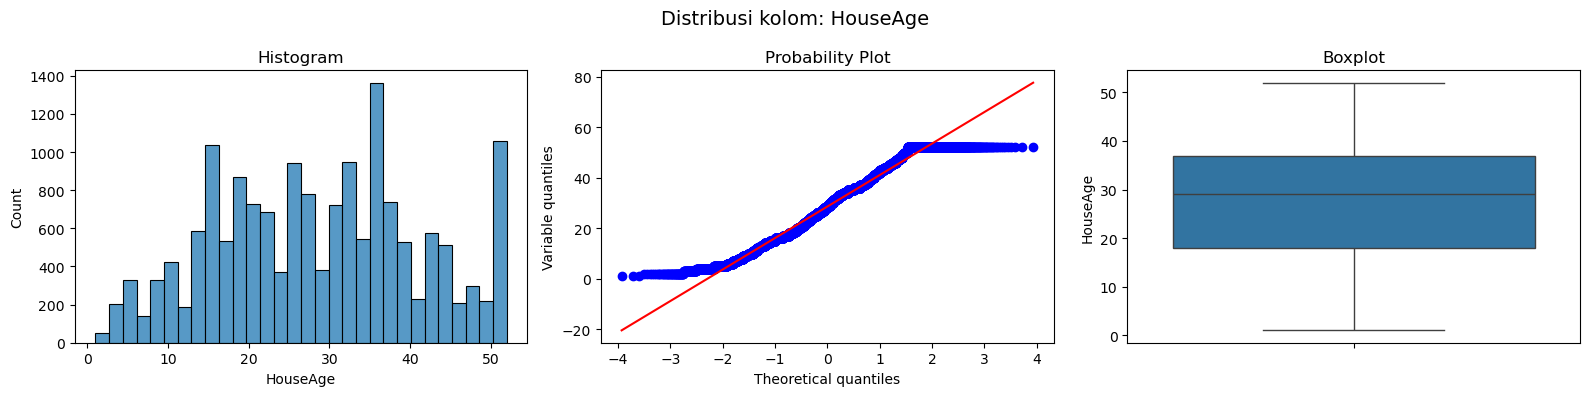

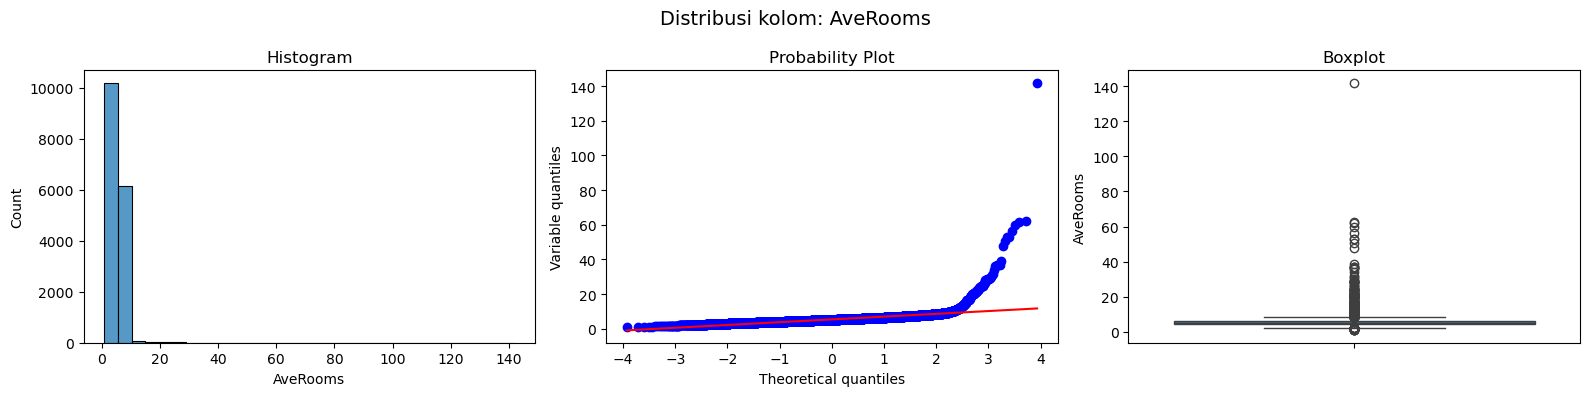

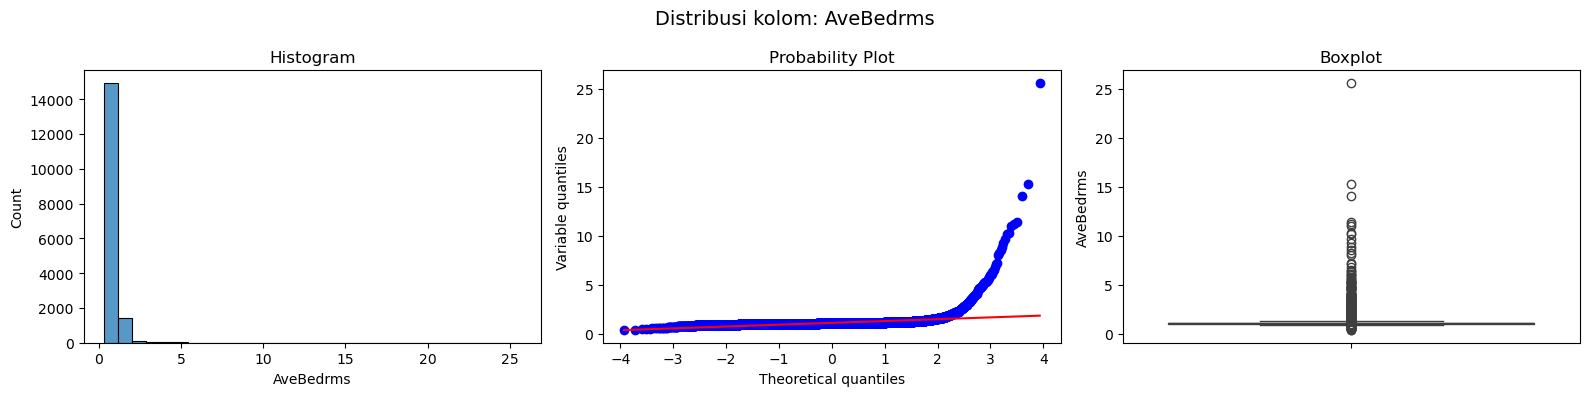

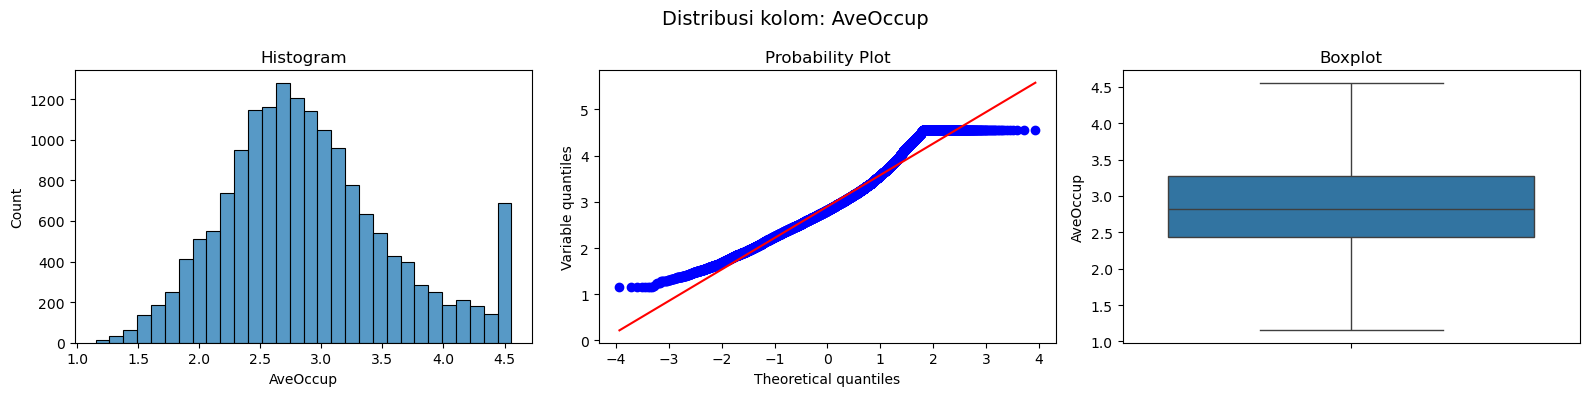

In [21]:
# Melakukan loop untuk mengecek distribusi tiap kolom
for kolom in kolom_kolom:
    check_plot(train_clfr, kolom)

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [23]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [39]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
train_company, test_company = train_test_split(df_company, test_size=0.2, random_state=42)
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [45]:
#Tulis jawaban missing value handling kolom Headquarters disini
missing_pct = (train_company['Headquarters'] == '-1').sum() / len(train_company) * 100
#print missing value handle 
missing_pct

np.float64(0.0)

In [52]:
#handling nilai [modus]
modus_hq_train = train_company[train_company['Headquarters'] != '-1']['Headquarters'].mode()[0]
train_company['Headquarters'] = train_company['Headquarters'].apply(
    lambda x: modus_hq_train if x == '-1' else x)
test_company['Headquarters'] = test_company['Headquarters'].apply(
    lambda x: modus_hq_train if x == '-1' else x)

train_company['Headquarters'].value_counts()

Headquarters
New York, NY                 53
San Francisco, CA            28
Chicago, IL                  20
Boston, MA                   13
Mc Lean, VA                  12
Westminster, CO              10
Reston, VA                    9
Cambridge, United Kingdom     8
Cambridge, MA                 8
San Jose, CA                  7
Bedford, MA                   7
Vienna, VA                    7
Woodbine, MD                  6
Mountain View, CA             6
Arlington, VA                 6
Herndon, VA                   6
Washington, DC                6
Saint Louis, MO               6
San Antonio, TX               5
Denver, CO                    5
Los Angeles, CA               5
Chantilly, VA                 5
Bethesda, MD                  5
Orlando, FL                   4
Pleasanton, CA                4
Memphis, TN                   4
Raleigh, NC                   4
Princeton, NJ                 4
Santa Cruz, CA                4
Austin, TX                    4
San Rafael, CA             

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [68]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [69]:
#Splitting terlebih dahulu
train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [70]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

#kolom streaming yg dipilih 
kolom_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

#mengganti nilai tak sesuai
for kolom in kolom_encode:
    df_churn[kolom] = df_churn[kolom].replace({'No internet service': 'No', 'No phone service': 'No'})

# Validasi dengan value_counts
for kolom in kolom_encode:
    print(f'-{kolom}-')
    print(df_churn[kolom].value_counts())
    # print()

-StreamingMovies-
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
-StreamingTV-
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
-TechSupport-
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
-DeviceProtection-
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
-OnlineBackup-
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
-OnlineSecurity-
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
-MultipleLines-
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64


In [71]:
train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

#Encoding label
label_encoder = LabelEncoder()

# fit_transform dan cek hasil 
for kolom in kolom_encode:
    train_churn[kolom] = label_encoder.fit_transform(train_churn[kolom])
    test_churn[kolom] = label_encoder.transform(test_churn[kolom])
train_churn[kolom_encode].value_counts().head() if False else train_churn[kolom_encode].describe()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.389954,0.387114,0.289137,0.342741,0.350018,0.285765,0.425453
std,0.487783,0.487133,0.453402,0.474668,0.477018,0.451818,0.494455
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [72]:

train_churn[kolom_encode].head(20)

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,1
6074,0,0,0,0,0,0,0
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,1
1212,0,0,0,0,0,0,0
2722,0,0,0,0,0,0,0
4006,0,0,0,0,0,0,0
6791,0,1,0,1,0,0,0
5466,0,0,0,0,0,0,0


## Selesai :)